# Boltzmann

In deze notebook beginnen we met een box met deeltjes die allemaal dezelfde beginsnelheid hebben. Door onderlinge botsingen ontstaat er een snelheidsverdeling. De snelheidsverdeling wordt beschreven met de Maxwell-Boltzmann verdeling: 

$$
    f(v)=\left[\frac{m}{2 \pi k_{\mathrm{B}} T}\right]^{3 / 2} 4 \pi v^2 \exp \left(-\frac{m v^2}{2 k_{\mathrm{B}} T}\right)
$$

de meest waarschijnlijke snelheid $v_p$ kan bepaald worden door de afgeleide te nemen van $f(v)$ naar $v$: 

$$
    v_p = \sqrt{\frac{2k_BT}{m}}
$$

en de gemiddelde snelheid $\langle v \rangle $ kan gevonden worden door $\langle v \rangle = \int_0\infty vf(v)dv$ werk je dit netjes uit volgt hieruit: 

$$
\langle v \rangle = \frac{2}{\sqrt{2}}v_p
$$

## Doelen
De evolutie van snelheidsdistributie als functie van de tijd bestuderen en bovenstaande theorie verifieren.

## Outline
- Simulatie met 100 deeltjes
- $v(0) = const.$
- bekijken $v_i(t)$ 
- bekijken $v$ in histogram
- verifiëren van bovenstaande vergelijkingen

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

In [2]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self, dt):
        self.r += self.v * dt # + 1/2 * a * dt**2  
    
    # Het updaten van de snelheid door zwaartekracht
    # def update_velocity(self, a, dt):
    #     """Update the particle's velocity."""
    #     self.v += a*dt
    
    # Het bepalen of er een botsing plaats vindt
    def collide_detection(self, other):
        return np.linalg.norm(self.r - other.r) < (self.R + other.R)
    
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [3]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
particles = []
N = 500
v_0 = 1
m_p = 1.0
dt = 0.04

# Aanmaken van deeltjes
for i in range(N):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=m_p, v=[vx, vy], r = pos, R=.5)) 


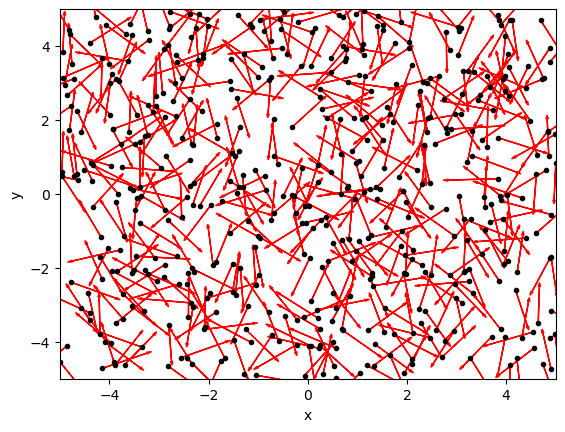

In [4]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],'k.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
              particle_object.v[0],particle_object.v[1], 
              head_width=0.05, head_length=0.1, color='red')
plt.show()


In [5]:
def handle_collisions(particles):
    ignore_list = []
    for i, p1 in enumerate(particles):
        if p1 in ignore_list:
            continue
        for j, p2 in enumerate(particles):
            if p1 is p2:
                continue
            if p1.collide_detection(p2):
                r1, r2 = p1.r, p2.r
                v1, v2 = p1.v, p2.v
                m1, m2 = p1.m, p2.m

                delta_r = r1 - r2
                delta_v = v1 - v2
                distance_squared = np.dot(delta_r, delta_r) + 1e-12  # voorkom deling door 0

                # Botsing oplossen volgens elastische botsing in 2D
                v1_new = v1 - 2 * m2 / (m1 + m2) * np.dot(delta_v, delta_r) / distance_squared * delta_r
                v2_new = v2 - 2 * m1 / (m1 + m2) * np.dot(-delta_v, -delta_r) / distance_squared * (-delta_r)

                p1.v = v1_new
                p2.v = v2_new

                ignore_list.append(p2)

In [6]:
for i in range(100):
    
    for p in particles:
        p.update_position(dt)    # Update positie
        p.boxcollision()         # Wandbotsing werkt per deeltje
        p.kin_energy             # Energie 
    handle_collisions(particles)


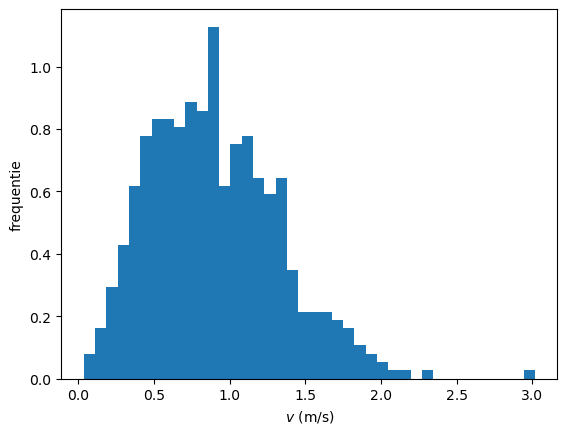

In [7]:
speeds = [np.linalg.norm(p.v) for p in particles]

plt.figure()
plt.xlabel('$v$ (m/s)')
plt.ylabel('frequentie')

plt.hist(speeds,bins=40,density='True')

plt.show()

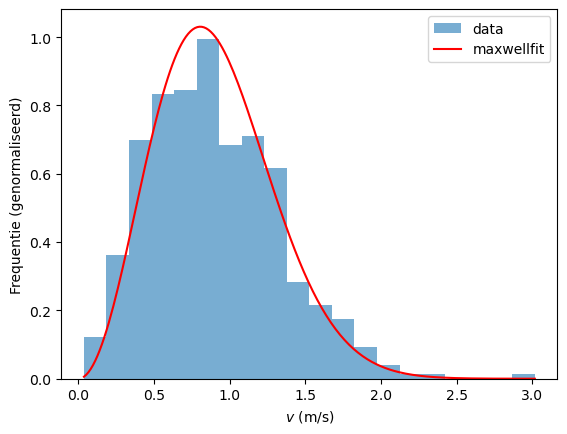

In [8]:
# Curve fitting
def maxwell(v,a):
    return (a/np.pi)**(3/2)*4*np.pi*v**2*np.exp(-a*v**2)

# Berekenen van histogram
counts, bin_edges = np.histogram(speeds, bins=20, density=True)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Vinden van de optimale paramters
popt, pcov = curve_fit(maxwell, bin_centers, counts)




plt.figure()

plt.xlabel('$v$ (m/s)')
plt.ylabel('Frequentie (genormaliseerd)')

plt.hist(speeds, bins=20, density=True, alpha=0.6, label="data")

x_fit = np.linspace(min(speeds), max(speeds), 200)
y_fit = maxwell(x_fit, *popt)

plt.plot(x_fit, y_fit, 'r-', label='maxwellfit')

plt.legend()
plt.show()

In [9]:
# Hier zou je boltzmann kunnen bereken 
# a = m/(2kbT)
# ofwel
# kb = m/(2aT)
# 1/2mv^2 = 3/2kT


SyntaxError: invalid decimal literal (1657525622.py, line 1)

# Energie herzien


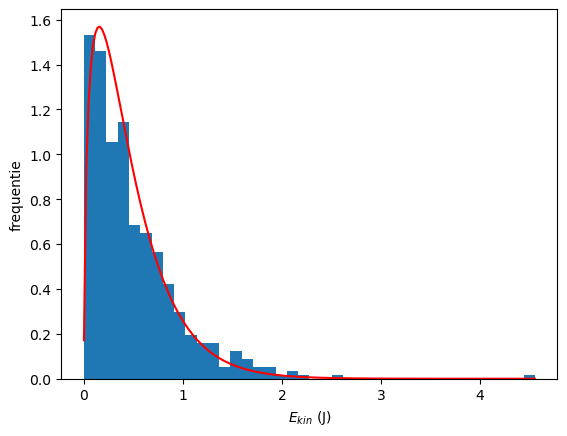

In [11]:
def E_th(E,a):
    return 2*np.sqrt(E/np.pi)*(1/a)**(3/2)*np.exp(-E/a)

energies = [p.kin_energy for p in particles]

# Berekenen van histogram
counts2, bin_edges2 = np.histogram(energies, bins=20, density=True)
bin_centers2 = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Vinden van de optimale paramters
popt, pcov = curve_fit(E_th, bin_centers2, counts2)

x_fit2 = np.linspace(min(energies), max(energies), 200)
y_fit2 = E_th(x_fit2, *popt)

plt.figure()
plt.xlabel('$E_{kin}$ (J)')
plt.ylabel('frequentie')

plt.hist(energies,bins=40,density='True')


plt.plot(x_fit2, y_fit2, 'r-', label='maxwellfit')


plt.show()